In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
import anndata as ad 
from importlib import reload
from scipy.sparse import coo_matrix

import h5py
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

from tqdm import tqdm
import pandas as pd

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

sns.set(style='white', context='notebook', rc={'figure.figsize':(6,6)}, font_scale=1.5)

# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import load_cluster_data as llc 

# Append also simulation directory
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
reload (sim)

sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/")
import vis as vis

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *
import cost_correlation_assign
from cost_correlation_assign import *

reload(masking)
reload(cost_correlation_assign)
import differential_splicing

2.3.0+cu121
12.1
2.3.0+cu121
12.1


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

float_type = { 
        "device": device, 
        "dtype": torch.float,
    }

Using device: cuda


### Load real brain single cell data from Tabula Senis

In [3]:
adata = ad.read_h5ad('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leafletall_ages_brain_intron_clusters_adata.h5ad')
adata.obs["cell_id_index"] = adata.obs.index

#cell_type_column = "cell_ontology_class"
#filter_clusters = True

cell_type_column = None
filter_clusters = False
K_use = 2

# Load Anndata object
adata_input = adata.copy()  # Make a copy to avoid modifying the original data
proportion_negative=0.99

# If cell type column is present in adata.obs, then set K to the number of unique cell types
if cell_type_column in adata.obs.columns:
    K = adata.obs[cell_type_column].nunique()
    
    # Print the unique cell types and their counts
    unique_cell_types = adata.obs[cell_type_column].value_counts()
    print(f"Unique cell types in '{cell_type_column}':")
    print(unique_cell_types)
else:
    K = K_use

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Remove lowly observed ATSEs!!

In [4]:
if filter_clusters:
    
    # Extract the cluster counts matrix (C x J) and cell types
    cluster_counts = adata_input.layers["Cluster_Counts"]
    cell_types = adata_input.obs[cell_type_column].values

    # Get unique cell types and clusters
    unique_cell_types = np.unique(cell_types)
    unique_clusters = adata_input.var_names # assuming var_names corresponds to junction clusters

    # Initialize a DataFrame to store the counts
    expression_counts = pd.DataFrame(0, index=unique_cell_types, columns=unique_clusters)

    # Calculate the number of cells expressing each intron cluster for each cell type
    for cell_type in tqdm(unique_cell_types):
        cells_in_type = (cell_types == cell_type)
        counts_in_type = cluster_counts.toarray()[cells_in_type, :].sum(axis=0) # number of cells in cell type found for each cluster pair 
        expression_counts.loc[cell_type] = counts_in_type  # .A converts sparse matrix to dense array

    # Calculate the number of cell types where each cluster has non-zero (and > 5) expression
    non_zero_counts = (expression_counts >= 0).sum(axis=0)

    # Calculate the threshold for filtering (25% of total cell types)
    threshold = len(expression_counts) * 0.2
    print(threshold) 

    # Filter clusters that are expressed in more than 25% of cell types
    filtered_clusters = non_zero_counts[non_zero_counts > threshold].index

    # Subset the original DataFrame to keep only the filtered clusters
    filtered_expression_counts = expression_counts[filtered_clusters]

    # Juncs to keep 
    juncs_keep = list(filtered_expression_counts)

    # Subset Anndata vars to only these adata_input.var_names along with adata layers 
    adata_filtered = adata_input[:, juncs_keep].copy()

    # need to ensure indices of junctions/clustesr are still concordant across var info and counts matrices 
    adata_filtered.var['junction_id_index'] = np.arange(adata_filtered.n_vars)
    adata_filtered.var_names = adata_filtered.var['junction_id_index'].astype(str)
    adata_filtered.layers["Cluster_Counts"].shape, adata_filtered.layers["Junction_Counts"].shape

else:
    adata_filtered = adata_input.copy()

### Simulate data!

In [5]:
cell_index_tensor, junc_index_tensor, my_data, adata_input = sim.simulate_and_prepare_data(adata_filtered, K, float_type, proportion_negative, cell_type_column)

The number of unique junctions included in the simulation data is: 17703
The number of unique clusters included in the simulation data is: 5901


100%|██████████| 5901/5901 [00:08<00:00, 664.85it/s]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


The proportion of negative ASEs to set is: 0.99
The number of cell types is: 2
The number of cells is: 12657
The number of junctions is: 17703
Number of negative labels (0): 5841
Number of positive labels (1): 60


100%|██████████| 5901/5901 [00:16<00:00, 348.41it/s]


Assertion passed: 'junction_id_index' matches the index in 'adata_input.var'.
Done simulating PSI!
Done simulating junction counts!
True label counts:
 true_label
negative    17580
positive      123
Name: count, dtype: int64
Sample label counts:
 sample_label
negative    17523
positive      180
Name: count, dtype: int64
12657
Data successfully simulated and prepared!


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/load_cluster_data.py:43: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ).to_sparse_csr()


In [6]:
# Index clean up 
adata_input.obs.drop(columns=['cell_id_index'], inplace=True)
adata_input.obs.reset_index(inplace=True)

In [7]:
adata_input.layers["Cluster_Counts"].shape, adata_input.layers["Junction_Counts"].shape

((12657, 17703), (12657, 17703))

     junction_id_index            junction_id  difference true_label
0                15363  8_119679457_119680154         0.0   negative
1494             15364  8_119679457_119681031         0.0   negative
1585             15365  8_119680238_119681031         0.0   negative
cell_type
1    1631
0    1496
Name: count, dtype: int64


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


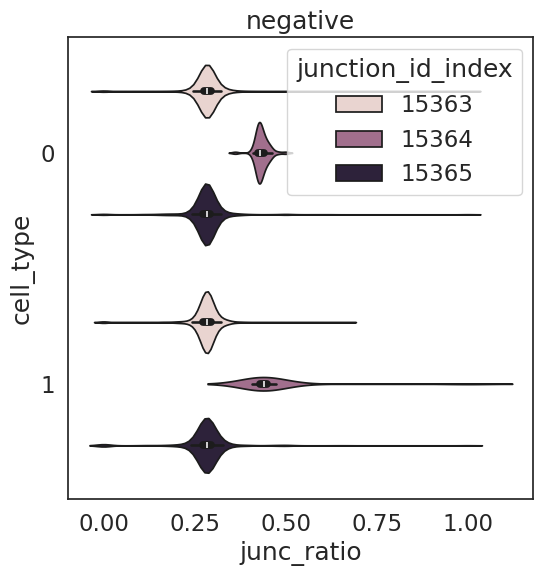

In [8]:
clust = np.random.choice(adata_input.var.Cluster.unique(), 1, replace=False)[0]
sim.quick_clust_plot(clust, adata_input)

In [9]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:747: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:431.)
  _C._set_default_tensor_type(t)


In [10]:
#### TO FIX BUG: SOMETIMES I GET --> 193 assert torch.all(assign >= 0), "Assign has negative values!"
    #194 # Assert that values in pi sum up to 1 
    #195 assert torch.allclose(pi.sum(), torch.tensor(1.0)), f"pi does not sum to 1: {pi.sum()}"
    # AssertionError: Assign has negative values!

In [11]:
reload(factor_model)
print(K)

# make input conc infinity first 
input_conc = torch.tensor(np.inf, **float_type)

plot_bb=False

# Convert the CSR tensor to COO format
full_y_tensor = my_data.ycount_lookup.to_sparse_coo()
full_total_counts_tensor = my_data.tcount_lookup.to_sparse_coo()

all_results, variable_sizes = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=2, use_global_prior=False, K=K, lr=0.1, input_conc_prior=input_conc, loss_plot=False, num_epochs=300, save_to_file = False)

Using a fixed probability of success across all trials (infinite concentration parameter) with a binomial distribution.
Not using priors on a and b, running simpler non-hierarchical version!


2.3.0+cu121
12.1
2
Random seeds: [7730, 1783]
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 7730
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
cuda
Training in progress for 300 epochs!
Epoch 0, Elbo loss: 2058392483.3498273
Epoch 20, Elbo loss: 1329453867.5323386
Epoch 40, Elbo loss: 705706876.9608077
Epoch 60, Elbo loss: 287784983.5877227
Epoch 80, Elbo loss: 107924623.75082505
Epoch 100, Elbo loss: 52744650.201097935
Epoch 120, Elbo loss: 33638138.670437835
Epoch 140, Elbo loss: 27138409.047677986
Epoch 160, Elbo loss: 22777468.354397837


In [ ]:
# figure out which index in all_results has the lowest final loss
losses = [result["losses"][-1] for result in all_results]
# get number of epochs for each initialization
num_epochs = [len(result["losses"]) for result in all_results]

# make a quick plot of the losses
plt.plot(losses)
plt.xlabel("Initialization")
plt.ylabel("Final Loss")
# make each loss value with a dot 
plt.scatter(range(len(losses)), losses)

# also mark the number of epochs
for i in range(len(losses)):
    plt.text(i, losses[i], str(num_epochs[i]), size="small")
# mark the lowest loss red
plt.scatter(np.argmin(losses), np.min(losses), color="red")

In [ ]:
# Let's get assign matrix for each initialization
assign_matrices = [result["summary_stats"]["assign"]["mean"] for result in all_results]
len(assign_matrices)

In [ ]:
corrs, matchings = compare_assignments(assign_matrices)

In [ ]:
sns.clustermap(corrs, annot=True)

In [ ]:
def average_pairwise_correlation(corrs):
    # Use tril_indices to access the lower triangle excluding the diagonal
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.mean(corrs[i, j])

def median_pairwise_correlation(corrs):
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.median(corrs[i, j])

def min_pairwise_correlation(corrs):
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.min(corrs[i, j])

# Calculate the average pairwise correlation
average_corr = average_pairwise_correlation(corrs)
print(f"Average Pairwise Correlation: {average_corr}")

median_corr = median_pairwise_correlation(corrs)
print(f"Median Pairwise Correlation: {median_corr}")

min_corr = min_pairwise_correlation(corrs)
print(f"Minimum Pairwise Correlation: {min_corr}")

In [ ]:
# get the index of initialization with the lowest loss
best_init = np.argmin(losses)
print("The best initialization was: ", best_init)

# extract latent variables for just first seed used 
latent_vars = all_results[best_init]['summary_stats'] 

pi = latent_vars["pi"]["mean"] # overall contribution of each factor to cell population, one value per k
dir_conc = latent_vars["dir_conc"]["mean"] # one scaling value 
assign_post = latent_vars["assign"]["mean"]
psis = latent_vars["psi"]["mean"] # psi is the probability of a junction being used in a cluster
a = latent_vars["a"]["mean"] 
b = latent_vars["b"]["mean"] 
#bb_conc = latent_vars["bb_conc"]["mean"] # concentration parameter for beta-binomial distribution

print(a)
print(b)

print("The inferred concentration parameter is: " + str(dir_conc))
print("The inferred pi parameter is: " + str(pi))
#print("The inferred bb_conc parameter is: " + str(bb_conc))

In [ ]:
J = psis.shape[1]

# Let's extract the values in .0.loc and .0.scale for each key in param store 
psis_mus = pyro.get_param_store()["AutoGuideList.0.loc"]
psis_loc = pyro.get_param_store()["AutoGuideList.0.scale"]

# reshape psis_mus and psis_loc to be K x J
psis_mus = psis_mus.reshape(K, J)
psis_loc = psis_loc.reshape(K, J)

# get the shape of psis_mus
psis_mus.shape, psis_loc.shape

In [ ]:
j = np.random.randint(J)

# let's do a sanity check that the mus and scales of PSIs would correspond to what we sample from the beta distribution posterior
# sample j from J 
print(f"Junction {j}")

# get mu_j and scale_j for junction j from variational params
mu_j = psis_mus[:,j]
scale_j = psis_loc[:,j]

print(f"Mean of PSIs: {mu_j}")
print(f"Scale of PSIs: {scale_j}")

# for each mu_kj and scale_kj we sample from a normal distribution with mean mu_kj and scale scale_kj
# use torch normal distirbution to sample one value for each k 

# sample from normal distribution, one value for each k
sampled_vals = torch.normal(mu_j, scale_j)

# calculate sigmoid of each value using torch 
sigmoid_vals = torch.sigmoid(sampled_vals)

In [ ]:
# initiate new tensor to store the sigmoid values 
psis_variational = torch.zeros(K, J)

# collect all the sigmoids values for each junction k 
for j in range(J):
    mu_j = psis_mus[:,j]
    scale_j = psis_loc[:,j]
    sampled_vals = torch.normal(mu_j, scale_j)
    sigmoid_vals = torch.sigmoid(sampled_vals)
    psis_variational[:,j] = sigmoid_vals

In [ ]:
psis_torch = torch.tensor(psis)
# compare psis and psis_variational
print("The correlation between the true PSIs and the variational PSIs is: ")
correlation = torch.nn.functional.cosine_similarity(psis_variational, psis_torch, dim=1)
correlation

### I think the order 

In [ ]:
# make UMAP using average assign_post across seeds and color points by cell_type 
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# run UMAP on assign_post matrix
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

In [ ]:
cell_types_series = pd.Series(adata_input.obs.cell_type.astype(str).values)
# Get unique cell types and assign colors
cell_types_unique = np.unique(cell_types_series)
cell_type_colors = sns.color_palette("tab20", len(cell_types_unique))
cell_type_dict = dict(zip(cell_types_unique, cell_type_colors))

# Map the cell types to their corresponding colors
cell_colors = cell_types_series.map(cell_type_dict).values

In [ ]:
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))

# Calculate the silhouette score
silhouette_avg = silhouette_score(assign_post, adata_input.obs.cell_type.values, metric='euclidean')

# Plot the UMAP embedding
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=5, c=cell_colors, alpha=0.5
)

# Add the silhouette score text on top of the plot
plt.text(0.05, 0.95, f'Silhouette Score: {silhouette_avg:.2f}', fontsize=12, transform=plt.gca().transAxes, verticalalignment='top')

# Create legend handles and labels
legend_handles = [mpatches.Patch(color=color, label=cell_type) for cell_type, color in cell_type_dict.items()]

# Add legend to the plot
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=8)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")

In [ ]:
# Create a list of colors for each cell based on its cell type
row_colors = cell_colors

# Use the custom color palette in your clustermap
cluster = sns.clustermap(
    data=assign_post,
    annot=False,
    yticklabels=False,
    figsize=(8, 8),
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
)


In [ ]:
# Now let's implement ALBF so can see which junctions are selected to be differentially spliced and then see if this corresponds to the true labels that were simulated
# load ALBF code from differential_splicing.py
reload(differential_splicing)

In [ ]:
def plot_logit_normal_distribution_with_samples(psis_mus, psis_loc, psis, j):

    """
    Plot the logit-normal distributions for each row using the mean and standard deviation provided for a specific column index j.

    :param psis_mus: Tensor of shape (2, N), means of the logit-normal distributions
    :param psis_loc: Tensor of shape (2, N), standard deviations of the logit-normal distributions
    :param j: Column index to select the mean and standard deviation
    """
    psis_mus = psis_mus.cpu().detach().numpy()  # Convert tensors to numpy arrays
    psis_loc = psis_loc.cpu().detach().numpy()
    
    # Extract the means and standard deviations for the specific column j
    means = psis_mus[:, j]
    std_devs = psis_loc[:, j]
    psi_samples_final = psis[:, j]

    # Create a plot
    plt.figure()

    for mean, std_dev, final_sample in zip(means, std_devs, psi_samples_final):
        # Sample values from the normal distribution of y
        y_samples = np.random.normal(mean, std_dev, 10000)
        # Transform y to psi
        psi_samples = 1 / (1 + np.exp(-y_samples))

        # Plot the histogram of the psi samples to show the distribution
        plt.hist(psi_samples, bins=100, density=True, alpha=0.6, label=f'Logit-Normal Dist (mean={mean}, std={std_dev})')

        # Plot the final sampled values of psi as a line
        plt.axvline(final_sample, color='grey', linestyle='--', linewidth=1, label=f'Sampled Value (psi={final_sample})')
        plt.xlim(0, 1)

    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title('Logit-Normal Distributions for Psi with Sampled Values')
    plt.grid(True)
    plt.show()

In [ ]:
import torch

def combined_mean_variance(means, variances):
    eps = 1e-10  # Small value to ensure numerical stability
    variances = torch.clamp(variances, min=eps)
    inv_variances = 1 / variances
    combined_variance = 1 / torch.sum(inv_variances, dim=0)
    combined_mean = combined_variance * torch.sum(means * inv_variances, dim=0)
    return combined_mean, combined_variance

def gaussian_pdf(x, mean, std):
    eps = 1e-10  # Small value to ensure numerical stability
    var = std ** 2 + eps
    denom = (2 * torch.pi * var) ** 0.5
    num = torch.exp(- (x - mean) ** 2 / (2 * var))
    return num / denom

def check_for_nan_inf(tensor, name):
    if torch.isnan(tensor).any():
        print(f"{name} contains NaN values")
    if torch.isinf(tensor).any():
        print(f"{name} contains infinity values")

def likelihood_under_null(means, variances):
    eps = 1e-10  # Small value to ensure numerical stability
    combined_mean, combined_variance = combined_mean_variance(means, variances)
    combined_std = combined_variance ** 0.5

    # Calculate the combined Gaussian PDF at zero
    combined_pdf_zero = gaussian_pdf(torch.tensor(0.0), combined_mean, combined_std)
    combined_pdf_zero = torch.clamp(combined_pdf_zero, min=eps)
    
    # Calculate the sum of logs of Gaussian PDFs evaluated at zero for each mean and std
    log_pdfs_zero = torch.log(gaussian_pdf(torch.tensor(0.0), means, variances ** 0.5) + eps)
    sum_log_pdfs_zero = torch.sum(log_pdfs_zero, dim=0)

    # Calculate the product of Gaussian PDFs evaluated at zero for each mean and std
    product_pdfs_zero = torch.prod(gaussian_pdf(torch.tensor(0.0), means, variances ** 0.5), dim=0)
    product_pdfs_zero = torch.clamp(product_pdfs_zero, min=eps)
    
    likelihood_H0 = product_pdfs_zero / combined_pdf_zero
    print(likelihood_H0)
    # Compute the full likelihood under null hypothesis
    #likelihood_H0 = torch.exp(sum_log_pdfs_zero) / combined_pdf_zero
    #print(likelihood_H0)
    
    # Check for NaN or infinity values
    check_for_nan_inf(combined_mean, "Combined Mean")
    check_for_nan_inf(combined_variance, "Combined Variance")
    check_for_nan_inf(combined_pdf_zero, "Combined PDF Zero")
    check_for_nan_inf(sum_log_pdfs_zero, "Sum Log PDFs Zero")
    check_for_nan_inf(likelihood_H0, "Likelihood H0")
    
    return likelihood_H0

def compute_albf(psis_mus, psis_loc):
    # Compute likelihood under H_0 for each junction
    likelihood_H0 = likelihood_under_null(psis_mus, psis_loc)

    # Compute ALBF for each junction
    albf = -torch.log(likelihood_H0)
    
    # Convert -0.0 to 0
    albf = torch.where(albf == -0.0, torch.tensor(0.0), albf)
    return albf, likelihood_H0

In [ ]:
albf, l0 = compute_albf(psis_mus, psis_loc+0.000000001)
l0 = l0.detach().cpu()
albf = albf.detach().cpu()
albf_df = pd.DataFrame(albf, columns=["ALBF"])
albf_df["junction_id_index"] = range(albf_df.shape[0])

In [ ]:
# turn psis into df and merge with combined_df give new junction_id_index column first 
psis_df = pd.DataFrame(psis.T)
psis_df["junction_id_index"] = psis_df.index
psis_df = psis_df.merge(albf_df, on = ["junction_id_index"])

In [ ]:
psis_df["learned_difference"] = psis_df.iloc[:, :K].std(axis=1)

In [ ]:
juncs_clusts_labs = adata_input.var[["junction_id_index", "difference", "true_label", "Cluster"]]
psis_df = psis_df.merge(juncs_clusts_labs)

In [ ]:
psis_df

In [ ]:
# Plot distribution of ALBF scores for true_label positive vs negative
plt.figure(figsize=(10, 6))
sns.histplot(data=psis_df, x='ALBF', hue='true_label', kde=True, bins=30, alpha=0.5)

plt.title('Distribution of ALBF Scores by True Label')
plt.xlabel('ALBF Score')
plt.ylabel('Density')
plt.show()

### Maybe go back to using "difference" from PSI observed rather than from "simulated" beta values juncs_clusts_labs

In [ ]:
# plot ALBF vs difference
plt.figure(figsize=(5,5))
sns.scatterplot(data = psis_df, x = "learned_difference", y = "ALBF")
# calcualte spearman correlation between ALBF and difference
correlation = psis_df["ALBF"].corr(psis_df["difference"], method="spearman")
print(correlation)

In [ ]:
# plot ALBF vs difference
plt.figure(figsize=(5,5))
sns.scatterplot(data = psis_df, x = "difference", y = "ALBF")
# calcualte spearman correlation between ALBF and difference
correlation = psis_df["ALBF"].corr(psis_df["difference"], method="spearman")
print(correlation)

In [ ]:
clust = adata_input.var[adata_input.var["junction_id_index"] == 1045]["Cluster"].values[0]

### An example that's meant to be positive by very small sample size (low number of cells?) quite a bit of a distribution so maybe less confident

In [ ]:
sim.quick_clust_plot(clust, adata_input)

In [ ]:
psis_df

In [ ]:
psis[:, 0], psis_variational[:, 0]

In [ ]:
psis[:, 1045], psis_variational[:, 1045]

In [ ]:
# Plot distribution of ALBF scores for true_label positive vs negative
plt.figure(figsize=(10, 6))
sns.histplot(data=psis_df, x='learned_difference', hue='true_label', kde=True, bins=30, alpha=0.5)

plt.title('Distribution of Learned Difference by True Label')
plt.xlabel('Learned Difference')
plt.ylabel('Density')
plt.show()

### Imputation analysis 